#  ResNet50 — Stringing Defect Detection

This notebook trains a **ResNet50** transfer-learning model to classify surface images as **Stringing** or **No Stringing**.

| Step | Description |
|------|-------------|
| 1 | Load & preprocess data |
| 2 | Build the model |
| 3 | Compile |
| 4 | Train |
| 5 | Evaluate |
| 6 | Save |

---
##  Imports & Configuration

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'      # suppress TF logs
os.environ['GRPC_VERBOSITY'] = 'ERROR'
os.environ['GLOG_minloglevel'] = '3'

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

E0000 00:00:1777067367.690386   14182 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777067367.719142   14182 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 1 — Load and Preprocess Data

* Point to `data/` folder (contains `Stringing/` and `No_Stringing/` sub-folders)
* Resize all images to **224 × 224**
* Normalize pixels to **[0, 1]**
* Split: **80 % train / 10 % validation / 10 % test**
* Apply **augmentation on training set only** (rotation, flip, brightness)
* Batch size = **32**

In [4]:
# ---------- paths ----------
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

# ---------- constants ----------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------- collect all file paths + labels ----------
import glob, random

stringing_files   = sorted(glob.glob(os.path.join(DATA_DIR, "Stringing", "*.jpg")))
no_stringing_files = sorted(glob.glob(os.path.join(DATA_DIR, "No_Stringing", "*.jpg")))

print(f"Stringing images    : {len(stringing_files)}")
print(f"No_Stringing images : {len(no_stringing_files)}")

# Label: Stringing = 1, No_Stringing = 0
all_files  = stringing_files + no_stringing_files
all_labels = [1] * len(stringing_files) + [0] * len(no_stringing_files)

# Shuffle together
combined = list(zip(all_files, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_files, all_labels = zip(*combined)
all_files  = list(all_files)
all_labels = list(all_labels)

total = len(all_files)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)

train_files, train_labels = all_files[:train_end],       all_labels[:train_end]
val_files,   val_labels   = all_files[train_end:val_end], all_labels[train_end:val_end]
test_files,  test_labels  = all_files[val_end:],          all_labels[val_end:]

print(f"\nTrain : {len(train_files)}")
print(f"Val   : {len(val_files)}")
print(f"Test  : {len(test_files)}")

Stringing images    : 2555
No_Stringing images : 1811

Train : 3492
Val   : 437
Test  : 437


### 1.1 — Build `tf.data` pipelines with augmentation

In [5]:
def load_and_preprocess(file_path, label):
    """Read an image file, decode, resize, and normalise to [0,1]."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


def augment(img, label):
    """Apply data-augmentation (training set only)."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    # Random rotation (up to 20 degrees ≈ 0.35 rad)
    # tf.image doesn't have random_rotation, so we use keras layer below
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Augmentation layer for rotation ---
rotation_layer = layers.RandomRotation(factor=0.06, seed=SEED)  # ~20°

def augment_with_rotation(img, label):
    img = rotation_layer(img, training=True)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Datasets ---
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files), seed=SEED)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment_with_rotation, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Data pipelines ready.")

I0000 00:00:1777067371.477366   14182 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Data pipelines ready.


### 1.2 — Visualise a batch of training images

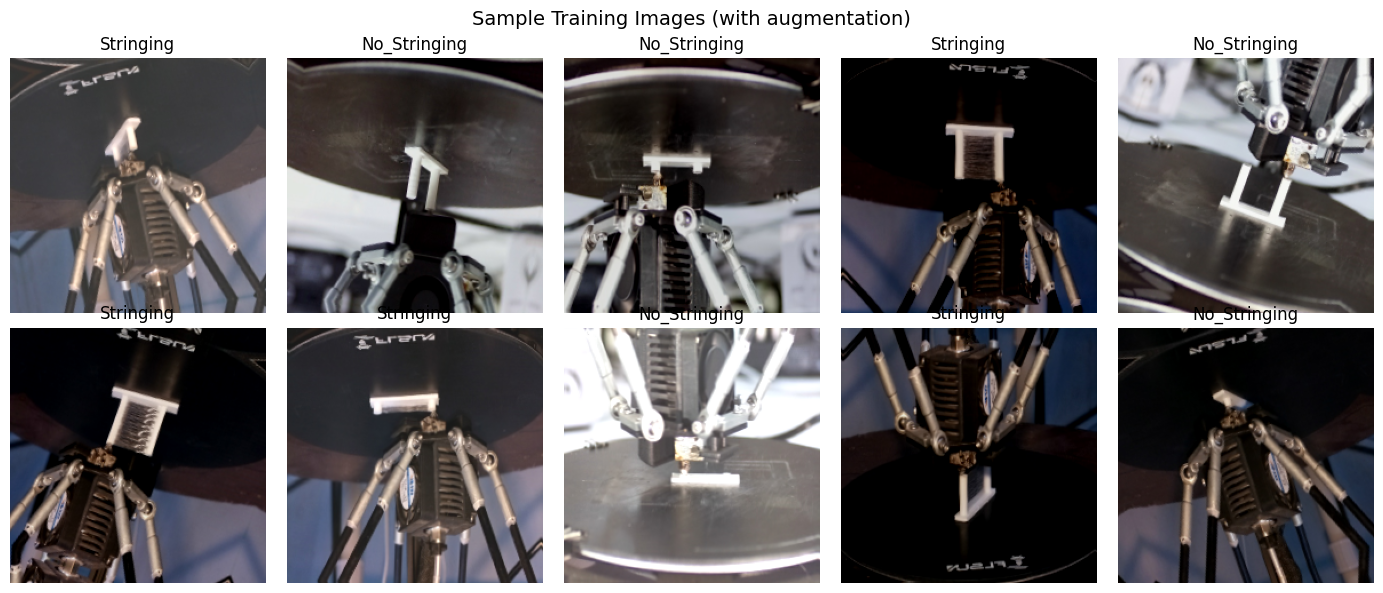

In [6]:
class_names = ["No_Stringing", "Stringing"]

plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(10, len(images))):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images (with augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2 — Build the Model

* Load **ResNet50** pretrained on ImageNet (`include_top=False`)
* **Freeze** all base layers
* Add: `GlobalAveragePooling2D → Dense(256, relu) → Dropout(0.3) → Dense(1, sigmoid)`

In [7]:
# ---------- Load pretrained base ----------
base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze all base layers
base_model.trainable = False

print(f"Base model layers : {len(base_model.layers)}")
print(f"Trainable weights : {len(base_model.trainable_weights)}")

# ---------- Build classification head ----------
inputs = keras.Input(shape=(224, 224, 3), name="input_image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3, name="dropout_03")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = keras.Model(inputs, outputs, name="ResNet50_Stringing")
model.summary()

Base model layers : 175
Trainable weights : 0


Model: "ResNet50_Stringing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

---
## Step 3 — Compile

* Optimizer: **Adam** (lr = 0.0001)
* Loss: **binary_crossentropy**
* Metrics: **accuracy**

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("✅ Model compiled.")

✅ Model compiled.


---
## Step 4 — Train

* Epochs: **50**
* Callbacks:
  * `EarlyStopping` — patience = 10, monitor `val_loss`
  * `ReduceLROnPlateau` — factor 0.5, patience 5
  * `ModelCheckpoint` — save best model

In [9]:
EPOCHS = 50
BEST_MODEL_PATH = "best_ResNet50_stringing.h5"

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
)

print("\n✅ Training complete.")

Epoch 1/50


I0000 00:00:1777067382.696008   14364 service.cc:148] XLA service 0x7ef20c002720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777067382.696053   14364 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
I0000 00:00:1777067384.265085   14364 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/110 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.3681 - loss: 0.8913 

I0000 00:00:1777067388.724899   14364 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5432 - loss: 0.7212
Epoch 1: val_loss improved from None to 0.67606, saving model to best_ResNet50_stringing.h5

Epoch 1: finished saving model to best_ResNet50_stringing.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - accuracy: 0.5441 - loss: 0.7096 - val_accuracy: 0.5721 - val_loss: 0.6761 - learning_rate: 1.0000e-04
Epoch 2/50
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5667 - loss: 0.6913
Epoch 2: val_loss improved from 0.67606 to 0.67020, saving model to best_ResNet50_stringing.h5

Epoch 2: finished saving model to best_ResNet50_stringing.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.5601 - loss: 0.6907 - val_accuracy: 0.5721 - val_loss: 0.6702 - learning_rate: 1.0000e-04
Epoch 3/50
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5719 - loss: 0.6874
Epoch 3: val_loss improved from 0.67020 to 0.66760, saving model to best_ResNet50_stringing.h5

Epoch 3: finished saving model to best_ResNet50_s

---
## Step 5 — Evaluate

* Load best saved model
* Run on test set
* Print: **accuracy, precision, recall, F1-score**
* Plot: **confusion matrix, ROC curve, training/validation accuracy & loss curves**

### 5.1 — Load best model & predict on test set

In [10]:
# Load best checkpoint
best_model = keras.models.load_model(BEST_MODEL_PATH)

# Predict
y_pred_probs = best_model.predict(test_ds).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = np.array(test_labels)

print(f"Test samples : {len(y_true)}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 351ms/step
Test samples : 437


### 5.2 — Classification metrics

In [11]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("="*50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("="*50)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

  Accuracy  : 0.6842
  Precision : 0.6658
  Recall    : 0.9423
  F1-Score  : 0.7803

              precision    recall  f1-score   support

No_Stringing       0.78      0.31      0.44       177
   Stringing       0.67      0.94      0.78       260

    accuracy                           0.68       437
   macro avg       0.72      0.62      0.61       437
weighted avg       0.71      0.68      0.64       437



### 5.3 — Confusion Matrix

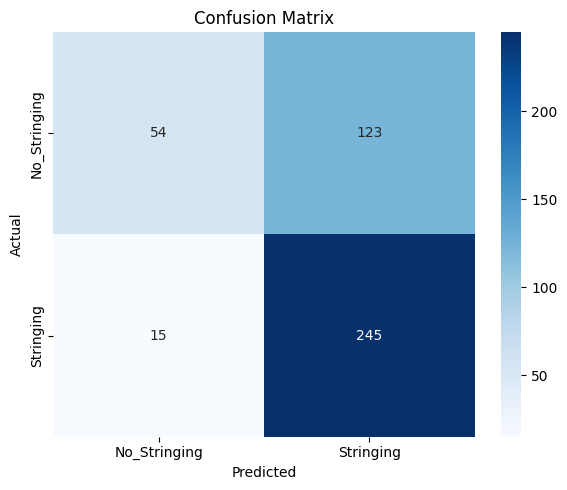

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### 5.4 — ROC Curve

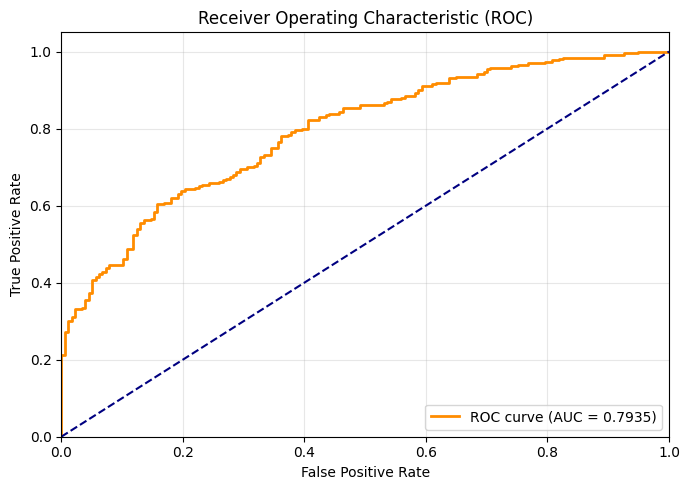

In [13]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 — Training / Validation Accuracy & Loss Curves

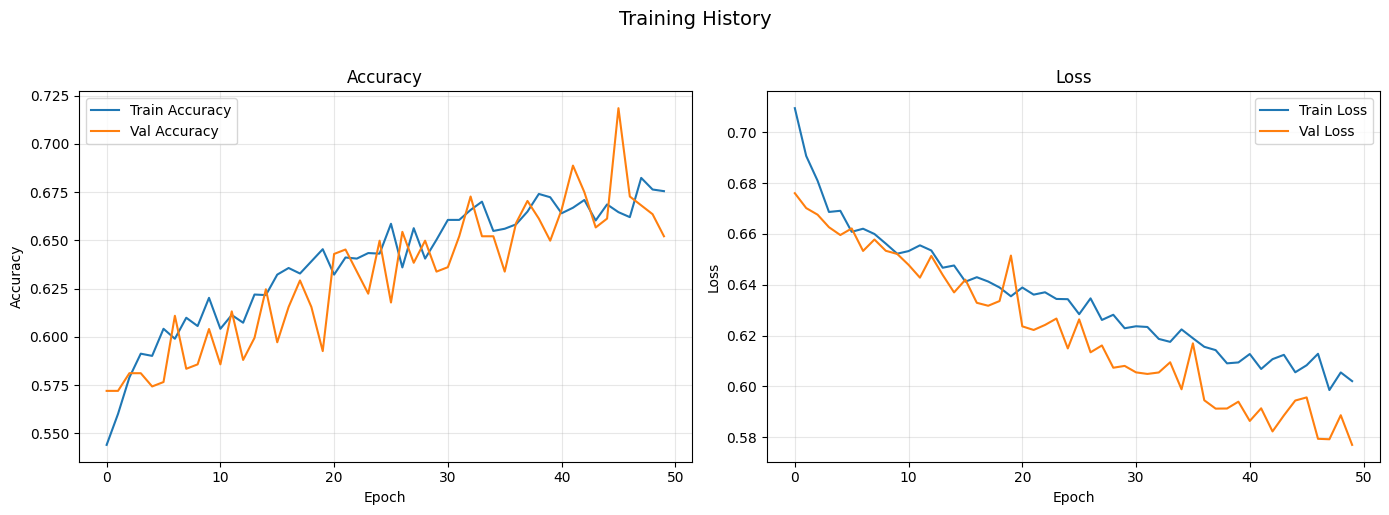

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],    label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6 — Save the Model

* Save as **`.h5`** (Keras format)
* Save as **`SavedModel`** format (for later TFLite conversion)

In [15]:
# 1) Save as .h5
H5_PATH = "ResNet50_stringing_final.h5"
best_model.save(H5_PATH)
print(f"✅ Model saved as HDF5       → {H5_PATH}")

# 2) Save as SavedModel directory
SAVED_MODEL_DIR = "ResNet50_stringing_savedmodel"
best_model.save(SAVED_MODEL_DIR)
print(f"✅ Model saved as SavedModel → {SAVED_MODEL_DIR}/")

✅ Model saved as HDF5       → ResNet50_stringing_final.h5


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=ResNet50_stringing_savedmodel.

---
### ✅ Done!

The trained ResNet50 model for **Stringing vs No_Stringing** detection is now saved and ready for deployment or TFLite conversion.